# 🚢 Titanic Survival Prediction

## 📌 Project Overview
This project uses passenger data from the Titanic disaster to predict whether a passenger survived or not. It is a classic **binary classification** problem and demonstrates key data science concepts:

- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Comparing Multiple Machine Learning Models
- Model Evaluation with Cross-Validation

📊 **Dataset:** Includes information such as age, gender, passenger class, fare, port of embarkation, etc.

🎯 **Target:** `Survived` (0 = Died, 1 = Survived)

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
pd.set_option('display.max_rows', None) 

## 1️⃣ Loading and Initial Data Exploration
I start by importing required libraries and loading the dataset and then examine the data structure, number of records, and check for missing values.

In [2]:
df = pd.read_csv("titanic.csv")
df.shape

(891, 12)

In [3]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
x = df[df["Age"].isnull()]
x

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
29,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.8958,NaN,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
32,33,1,3,"Glynn, Miss. Mary Agatha",female,NaN,0,0,335677,7.7500,NaN,Q
36,37,1,3,"Mamee, Mr. Hanna",male,NaN,0,0,2677,7.2292,NaN,C
42,43,0,3,"Kraeff, Mr. Theodor",male,NaN,0,0,349253,7.8958,NaN,C


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.dropna(subset=["Embarked"], inplace= True)

In [7]:
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [8]:

df["Age"] = df["Age"].fillna(df["Age"].median())

## 2️⃣ Exploratory Data Analysis (EDA)

In this section, we analyze how each feature impacts survival chances.

### 2.1 Impact of Passenger Class (Pclass)

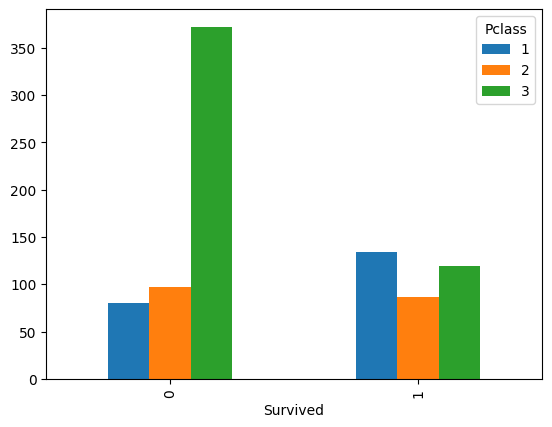

In [9]:
counts = pd.crosstab(df["Survived"], df["Pclass"])
counts.plot(kind="bar")
plt.show()

### 2.2 Impact of Gender (Sex)

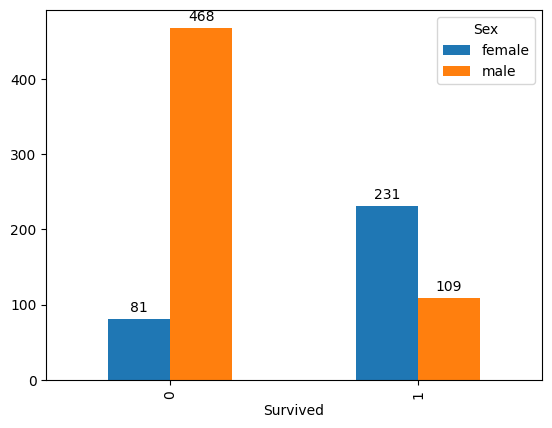

In [10]:
counts = pd.crosstab(df["Survived"], df["Sex"])
ax = counts.plot(kind="bar")
ax.bar_label(ax.containers[0], label_type='edge', padding=3)
ax.bar_label(ax.containers[1], label_type='edge', padding=3)
plt.show()

### 2.3 Impact of Age (Age)

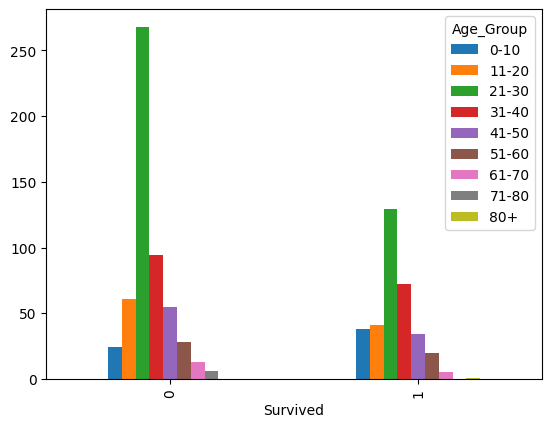

In [11]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '80+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
counts = pd.crosstab(df["Survived"], df["Age_Group"])
counts.plot(kind="bar")
plt.show()

In [12]:
df = df.drop(columns=["Age_Group"])

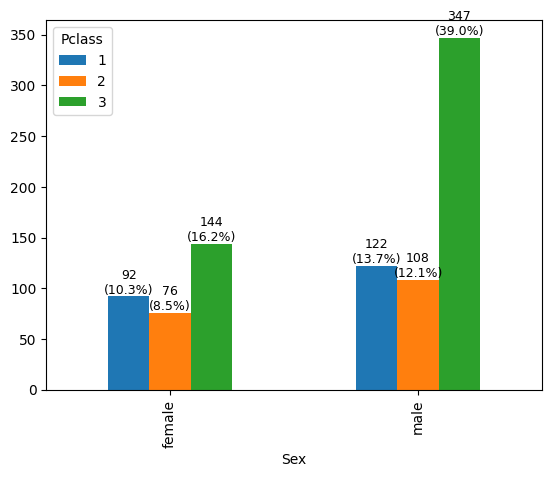

In [13]:

counts = pd.crosstab(df["Sex"], df["Pclass"])

counts_pct = pd.crosstab(df["Sex"], df["Pclass"], normalize='all') * 100

ax = counts.plot(kind="bar")

for container in ax.containers:
    labels = []
    for v in container:
        height = v.get_height()
        total = counts.sum().sum()  
        pct = (height / total) * 100
        labels.append(f'{int(height)}\n({pct:.1f}%)')
    ax.bar_label(container, labels=labels, fontsize=9)


plt.show()

### 2.4 Impact of Parents and Child (Parch)

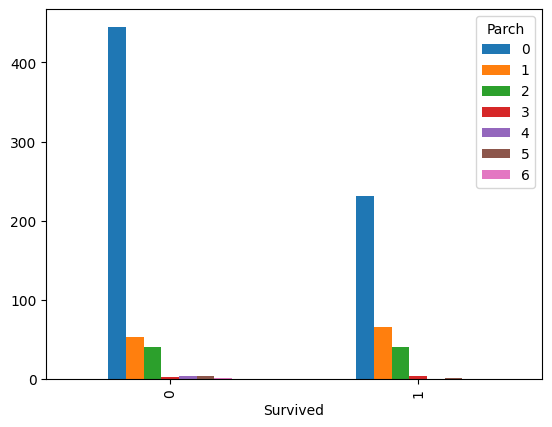

In [14]:
counts = pd.crosstab(df["Survived"], df["Parch"])
counts.plot(kind="bar")
plt.show()

### 2.5 Impact of siblings and spouse

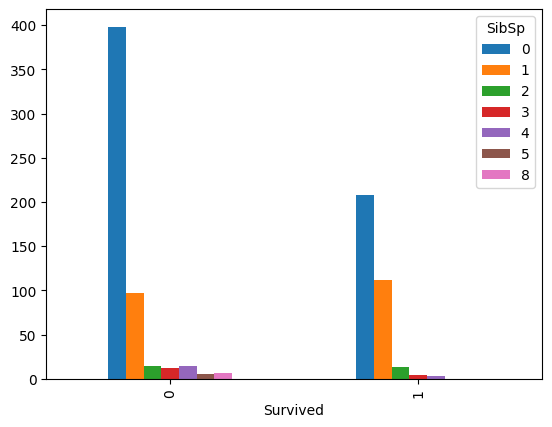

In [15]:
counts = pd.crosstab(df["Survived"], df["SibSp"])
counts.plot(kind="bar")
plt.show()

### 2.6 Impact of Cabin

In [16]:
print(df["Cabin"].value_counts())

Cabin
Unknown            687
G6                   4
C23 C25 C27          4
B96 B98              4
F33                  3
E101                 3
F2                   3
D                    3
C22 C26              3
C123                 2
D33                  2
C52                  2
C83                  2
F G73                2
D26                  2
B58 B60              2
C2                   2
E33                  2
F4                   2
D36                  2
C93                  2
C78                  2
D35                  2
B77                  2
E67                  2
C125                 2
B49                  2
C65                  2
B57 B59 B63 B66      2
B18                  2
C124                 2
B35                  2
E44                  2
C92                  2
D20                  2
E25                  2
B22                  2
C68                  2
C126                 2
B51 B53 B55          2
B5                   2
B20                  2
E24                  2
E8   

In [17]:
def get_first_letter(value):
    if value == "Unknown":
        return value
    else:
        value = value.strip()
        value = value[0]
        return value
df["Cabin"] = df["Cabin"].apply(get_first_letter)

In [18]:
df = df[df["Cabin"] != "T"]

In [19]:
print(df["Cabin"].value_counts())

Cabin
Unknown    687
C           59
B           45
D           33
E           32
A           15
F           13
G            4
Name: count, dtype: int64


### 2.7 Impact of Cabin 

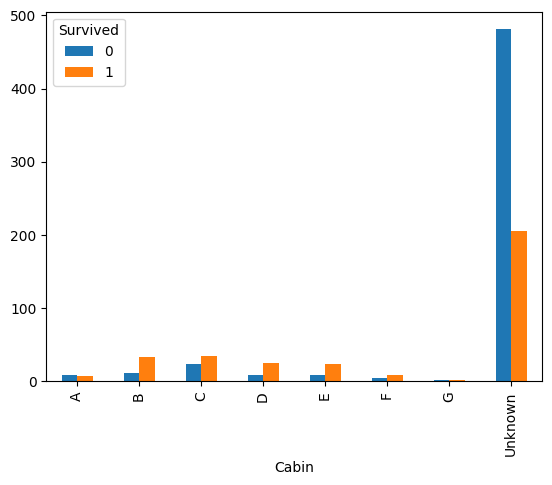

In [20]:
alive = pd.crosstab(df["Cabin"], df["Survived"])
alive.plot(kind="bar")
plt.show()

### 2.8 Impact of Embarked

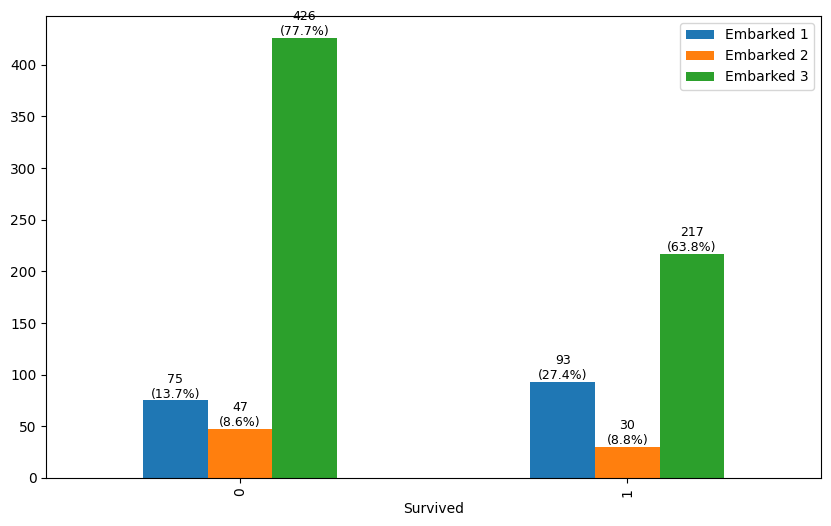

In [21]:

counts = pd.crosstab(df["Survived"], df["Embarked"])
counts_per = pd.crosstab(df["Survived"], df["Embarked"], normalize='index') * 100

ax = counts.plot(kind="bar", figsize=(10, 6))

for i, container in enumerate(ax.containers):
    labels = []
    for j, v in enumerate(container):
        height = v.get_height()
        if height > 0:
            per = counts_per.iloc[j, i]
            labels.append(f'{int(height)}\n({per:.1f}%)')
        else:
            labels.append('')
    ax.bar_label(container, labels=labels, fontsize=9)


plt.legend( labels=["Embarked 1", "Embarked 2", "Embarked 3"])
plt.show()




## 3️⃣ Outlier Detection and Removal

### 3.1 Outlier Removal in Fare Feature

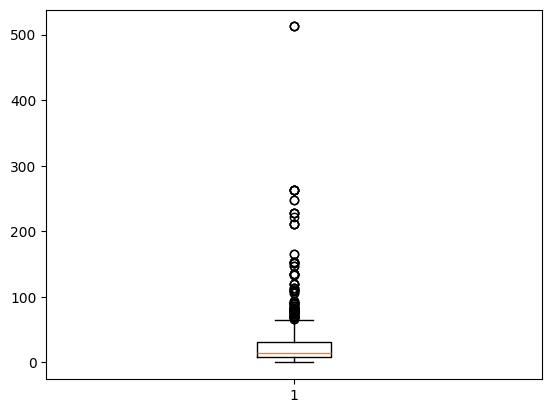

In [22]:
plt.boxplot(df["Fare"])
plt.show()

In [23]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
outliers =df[(df["Fare"] < Q1 - 1.5*IQR)&( df["Fare"] > Q3 + 1.5*IQR)]

outliers


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [24]:
print(df.groupby("Pclass")["Fare"].mean())

Pclass
1    84.422124
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [25]:
print(df["Fare"].describe())

count    888.000000
mean      32.092848
std       49.725379
min        0.000000
25%        7.895800
50%       14.454200
75%       30.771850
max      512.329200
Name: Fare, dtype: float64


In [26]:
df = df[df["Fare"] < 500]


In [27]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

### 3.2 Outlier Removal in Age Feature

{'whiskers': [<matplotlib.lines.Line2D at 0x1ebf0e09220>,
 'caps': [<matplotlib.lines.Line2D at 0x1ebf0e09730>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ebf0e08f50>],
 'medians': [<matplotlib.lines.Line2D at 0x1ebf0e09d30>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ebf0e0a000>],
 'means': []}

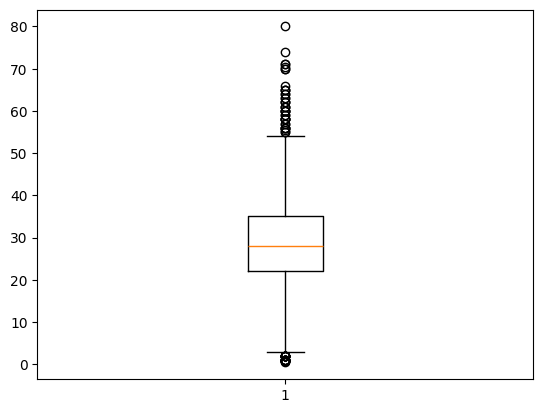

In [28]:
plt.boxplot(df["Age"])

In [29]:
df["Age"].describe()

count    885.000000
mean      29.277028
std       12.998768
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [30]:
agezero = df[(df["Age"] < 10)]
agezero

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,Unknown,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.00,1,1,PP 9549,16.7000,G,S
16,17,0,3,"Rice, Master. Eugene",male,2.00,4,1,382652,29.1250,Unknown,Q
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.00,3,1,349909,21.0750,Unknown,S
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.00,1,2,SC/Paris 2123,41.5792,Unknown,C
50,51,0,3,"Panula, Master. Juha Niilo",male,7.00,4,1,3101295,39.6875,Unknown,S
58,59,1,2,"West, Miss. Constance Mirium",female,5.00,1,2,C.A. 34651,27.7500,Unknown,S
63,64,0,3,"Skoog, Master. Harald",male,4.00,3,2,347088,27.9000,Unknown,S
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,Unknown,S
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.00,4,2,347082,31.2750,Unknown,S


## 4️⃣ Encoding Categorical Features
- Sex: male → 1, female → 0
- Embarked: S → 1, C → 2, Q → 3
- Cabin: mapped to numbers 1–7 (based on first letter) and -1 for unknown
- We also drop `Name` and `Ticket` and `PassengerId` columns as they are not directly useful.

In [31]:
df["Sex"] = df["Sex"].map({"male":1, "female":0})

In [32]:
print(df["Embarked"].value_counts())

Embarked
S    643
C    165
Q     77
Name: count, dtype: int64


### s==>1
### c==>2
### q==>3

In [33]:
df["Embarked"] = df["Embarked"].map({"S":1, "C":2, "Q":3})

In [34]:
print(df["Cabin"].value_counts())

Cabin
Unknown    686
C           59
B           43
D           33
E           32
A           15
F           13
G            4
Name: count, dtype: int64


In [35]:
df["Cabin"] = df["Cabin"].map({"A":1, "B":2, "C":3, "D":4, "E":5, "F":6, "G":7, "Unknown":-1})

In [36]:
df = df.drop(columns= ["PassengerId"])
df = df.drop(columns=["Name"])
df = df.drop(columns=["Ticket"])

## 5️⃣ Feature Selection & Correlation Analysis

The correlation matrix helps us understand which features have the strongest relationship with the target column (`Survived`).

<Axes: >

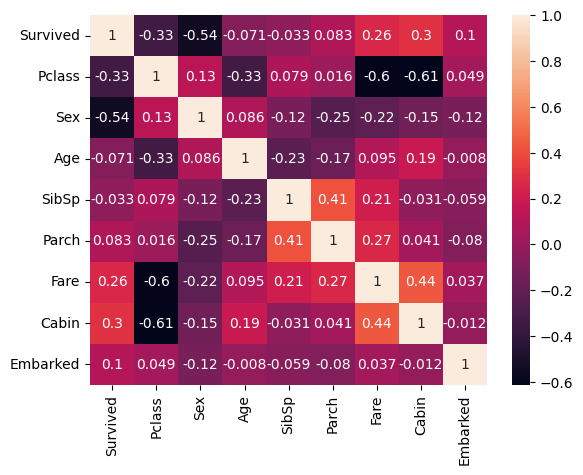

In [37]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True)

In [38]:
df = df.drop(columns=["Embarked"])

## 6️⃣ Data Preparation for Modeling
- Separate features (X) and target (y)
- Split data into training and test sets (80% / 20%)
- Apply Standardization to improve model performance

In [39]:
y = df["Survived"]
x = df.drop(columns=["Survived"])

In [40]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [41]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)

## 7️⃣ Model Building and Comparison

We evaluate the following models using **5-Fold Cross-Validation**:

- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)
- K-Neighbors (KNN)
- Decision Tree
- XGBoost

**Evaluation Metrics:** F1-Score (primary) and Accuracy

📊 Final results are displayed in the table and bar charts below.

Logistic Regression  | CV F1: 0.8066 (±0.0230) | Test Acc: 0.8136
Random Forest        | CV F1: 0.8155 (±0.0308) | Test Acc: 0.7740
SVM                  | CV F1: 0.8198 (±0.0161) | Test Acc: 0.8023
KNN                  | CV F1: 0.7989 (±0.0279) | Test Acc: 0.8023
Decision Tree        | CV F1: 0.7820 (±0.0198) | Test Acc: 0.7684
XGBClassifier        | CV F1: 0.8048 (±0.0240) | Test Acc: 0.8305

MODEL COMPARISON REPORT
              Model Accuracy Precision Recall F1-Score
      XGBClassifier   0.8305    0.8292 0.8305   0.8269
Logistic Regression   0.8136    0.8111 0.8136   0.8110
                KNN   0.8023    0.7995 0.8023   0.7995
                SVM   0.8023    0.7997 0.8023   0.7976
      Random Forest   0.7740    0.7706 0.7740   0.7714
      Decision Tree   0.7684    0.7652 0.7684   0.7662


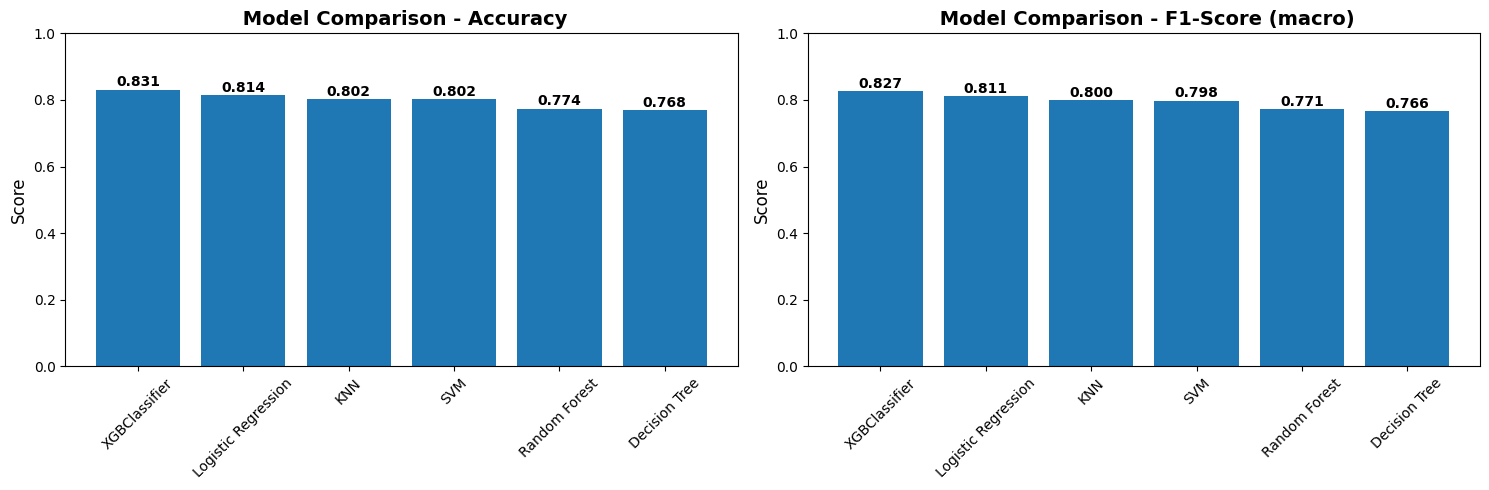

In [42]:

classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBClassifier': XGBClassifier(random_state=42)
}
cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
results = {}

for name, model in classifiers.items():
   
    cv_score = cross_val_score(model, X_train_scaled, Y_train, cv=cv, scoring='f1_weighted')
    model.fit(X_train_scaled, Y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'cv_mean': cv_score.mean(),
        'cv_std': cv_score.std()
    }
for name, data in results.items():
    print(f"{name:20} | CV F1: {data['cv_mean']:.4f} (±{data['cv_std']:.4f}) | Test Acc: {accuracy_score(Y_test, data['y_pred']):.4f}")
model_names = []
accuracies = []
precisions = []
recalls = []
f1_scores = []

for name, model_data in results.items():
    y_pred = model_data['y_pred']
    
    model_names.append(name)
    accuracies.append(accuracy_score(Y_test, y_pred))
    precisions.append(precision_score(Y_test, y_pred, average='weighted'))
    recalls.append(recall_score(Y_test, y_pred, average='weighted'))
    f1_scores.append(f1_score(Y_test, y_pred, average='weighted'))

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
}).sort_values('F1-Score', ascending=False)

comparison_df = comparison_df.reset_index(drop=True)


print("\n" + "="*70)
print("MODEL COMPARISON REPORT")
print("="*70)

display_df = comparison_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")

print(display_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


bars1 = axes[0].bar(comparison_df['Model'], comparison_df['Accuracy'])
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title(' Model Comparison - Accuracy', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 1)

for bar, val in zip(bars1, comparison_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

bars2 = axes[1].bar(comparison_df['Model'], comparison_df['F1-Score'])
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title(' Model Comparison - F1-Score (macro)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 1)

for bar, val in zip(bars2, comparison_df['F1-Score']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

#